In [1]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import numpy as np

In [2]:
df = pd.read_csv("df_imputed.csv")

In [3]:
df

,pride_national,pride_religious,strongleader,limitedelections,erdoganmission,erdoganinspiring,akpstate,akpmuslims,trust_religiousauthority,trust_presidentialsystem,success_erdogan,success_economyminister,policy_povertyreduction,policy_economy,policy_internalsecurity,ci_lifequality,ri_system_1,regimevoter
0,100,100,80,80,100,60,100,100,80,80,80,60,40,60,80,40,1.0,1.0
1,76,68,20,20,20,20,20,40,40,20,28,20,20,20,40,20,1.0,0.0
2,20,72,20,20,20,20,20,20,20,20,40,40,20,20,40,20,1.0,0.0
3,60,80,80,80,100,100,40,100,80,80,60,60,80,60,60,80,5.0,1.0
4,100,100,20,20,40,20,20,40,20,20,20,20,20,20,40,40,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6255,20,56,44,60,60,40,32,80,36,32,48,32,40,40,80,20,2.2,0.0
6256,60,60,100,100,60,100,100,60,80,100,60,60,60,60,40,68,3.8,1.0
6257,100,100,100,100,100,100,100,40,100,100,100,100,100,60,80,40,2.0,1.0
6258,100,100,88,76,100,100,100,80,80,100,100,80,80,80,100,80,5.0,1.0


# PCA

In [5]:
features = df.drop(columns=['regimevoter'], errors='ignore')
scaled = StandardScaler().fit_transform(features)
pca = PCA()
pca_fit = pca.fit(scaled)

<Axes: xlabel='PC1', ylabel='PC2'>

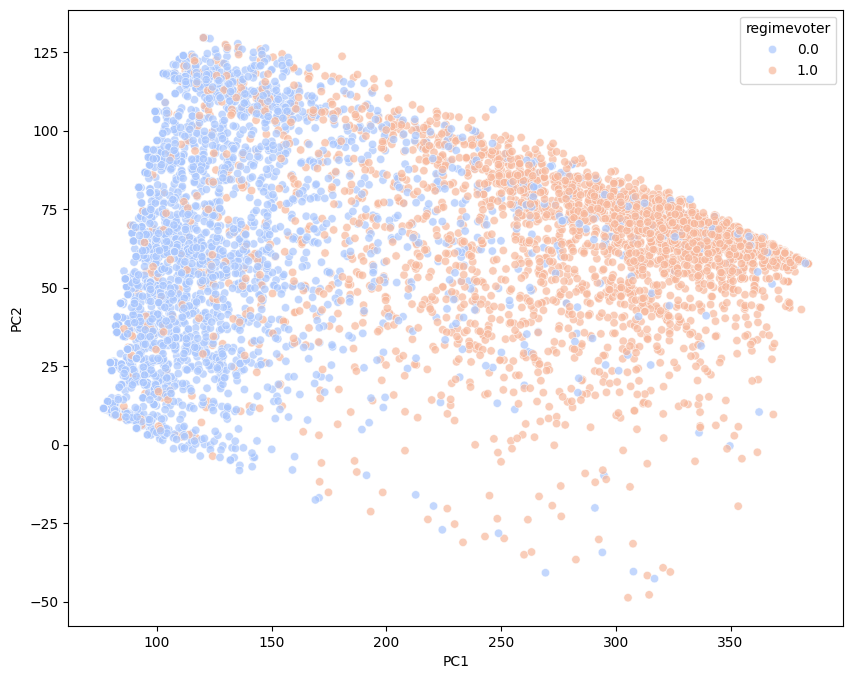

In [7]:
pc_df = pd.DataFrame(pca.transform(features), columns=[f"PC{i+1}" for i in range(features.shape[1])])
pc_df['regimevoter'] = df['regimevoter']

plt.figure(figsize=(10, 8))
sns.scatterplot(data=pc_df, x='PC1', y='PC2', hue='regimevoter', palette='coolwarm', alpha=0.7)

# LLE

In [9]:
from sklearn.datasets import load_digits
from sklearn.manifold import LocallyLinearEmbedding as LLE
import plotly.express as px
from sklearn.datasets import make_swiss_roll
from sklearn.model_selection import GridSearchCV
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.colors as mcolors
from sklearn.metrics import pairwise_distances
from sklearn.pipeline import Pipeline
import seaborn as sns

In [28]:
results = []
for k in [3, 5, 7, 10, 15, 18, 19, 20]:
    try:
        lle = LLE(n_neighbors=k, n_components=2, eigen_solver='dense')  
        dist = lle.fit_transform(scaled)
        orig = pairwise_distances(scaled)
        new = pairwise_distances(dist)
        rho = np.corrcoef(orig.flatten(), new.flatten())[0, 1]
        results.append((k, rho))
        print(f" k = {k}, corr = {rho:}")
    except Exception as e:
        print('ошибка')
if results:
    best_k, best_rho = max(results, key=lambda x: x[1])
    print(f" Best k = {best_k}, with correlation = {best_rho:.4f}")
else:
    print('')

 k = 3, corr = 0.04679920097364425
 k = 5, corr = 0.12514507433758346
 k = 7, corr = 0.36591443156268944
 k = 10, corr = 0.07069163203174665
 k = 15, corr = 0.06999730186541572
 k = 18, corr = 0.007730724145890823
 k = 19, corr = 0.18783496960557367
 k = 20, corr = 0.21902219758309383
 Best k = 7, with correlation = 0.3659


In [30]:
lle= LLE(n_neighbors=7, n_components=2)
lle_fit = lle.fit_transform(scaled)
lle_df = pd.DataFrame(lle_fit, columns=["Dim1", "Dim2"])
lle_df["vote"] = df["regimevoter"].map({0: "-", 1: "+"})

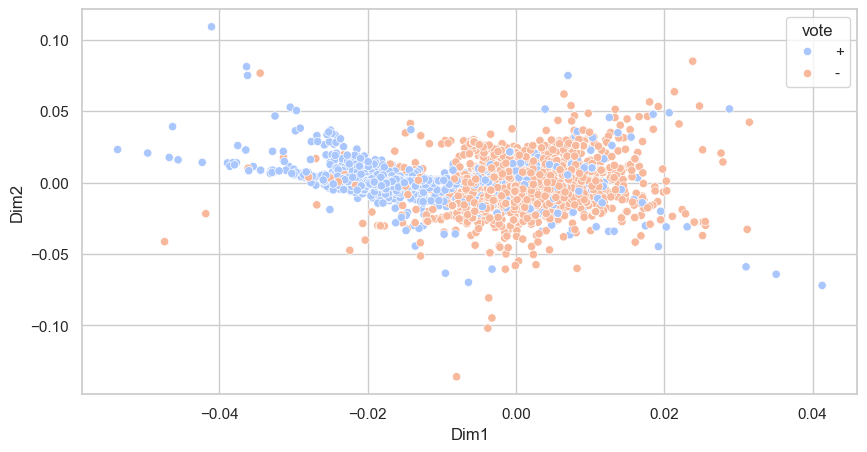

In [33]:
sns.set(style="whitegrid")
plt.figure(figsize=(10, 5))
sns.scatterplot(data=lle_df, x="Dim1", y="Dim2", hue="vote", palette="coolwarm")
plt.show()